In [7]:
##LIBRERIAS###
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.constants import mu_0


In [8]:
def leer_columnas(path_archivo):
    columnas = []

    with open(Path(path_archivo), "r", encoding="latin-1", errors="ignore") as f:
        next(f)  # <<< aquí saltamos la primera línea siempre
        for linea in f:
            partes = linea.strip().replace(",", ".").split()
            
            try:
                fila = [float(x) for x in partes]
                
                if not columnas:
                    columnas = [[] for _ in range(len(fila))]
           
                for i, val in enumerate(fila):
                    columnas[i].append(val)
            except ValueError:
                # Si no puede convertir, simplemente ignora esa fila
                continue

    return np.array(columnas)


Ajuste lineal corriente vs B 


Pendiente  = 25.3271 ± 0.0043 mT/A
Intercepto = 2.5189 ± 0.0080 mT


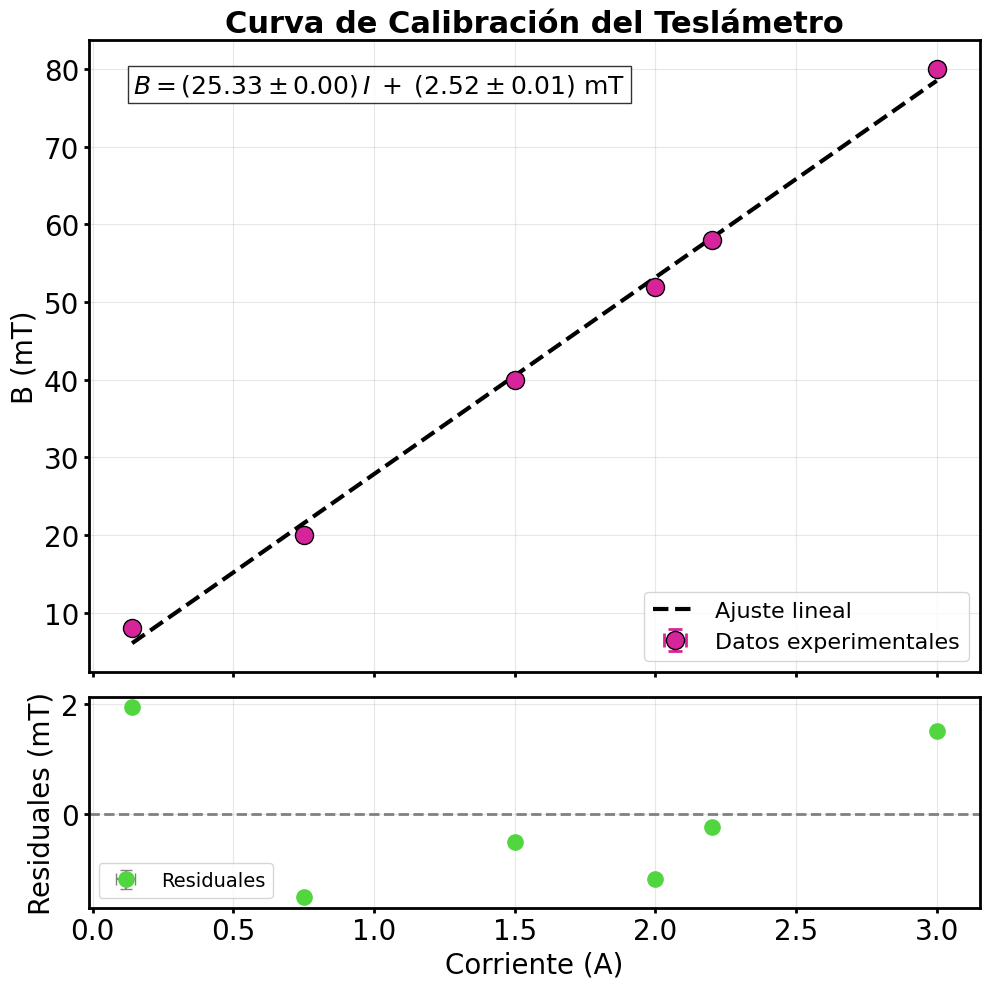

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# ======================================================
#   DATOS DE CALIBRACIÓN
# ======================================================

I_cal = np.array([0.14, 1.50, 0.75, 2.00, 2.20, 3.00])
B_cal_mT = np.array([8.0, 40.0, 20.0, 52.0, 58.0, 80.0])

# Errores instrumentales (explícitos)
err_I = np.ones_like(I_cal) * 0.01    # 0.01 A
err_B = np.ones_like(B_cal_mT) * 0.01 # 0.01 mT


# ======================================================
#   AJUSTE LINEAL PONDERADO: B = m I + b
# ======================================================

def ajuste_lineal(I, B_mT, err_B):
    """
    Ajuste lineal ponderado:
        B = m I + b
    usando pesos w = 1/sigma_B^2
    """
    w = 1.0 / err_B**2

    S   = np.sum(w)
    Sx  = np.sum(w * I)
    Sy  = np.sum(w * B_mT)
    Sxx = np.sum(w * I**2)
    Sxy = np.sum(w * I * B_mT)

    Delta = S * Sxx - Sx**2

    m = (S * Sxy - Sx * Sy) / Delta
    b = (Sxx * Sy - Sx * Sxy) / Delta

    # Errores de la pendiente y el intercepto
    dm = np.sqrt(S / Delta)
    db = np.sqrt(Sxx / Delta)

    return m, b, dm, db


m, b, dm, db = ajuste_lineal(I_cal, B_cal_mT, err_B)

print("Pendiente  = {:.4f} ± {:.4f} mT/A".format(m, dm))
print("Intercepto = {:.4f} ± {:.4f} mT".format(b, db))


# ======================================================
#   CURVA DE AJUSTE Y RESIDUALES
# ======================================================

I_aj = np.linspace(I_cal.min(), I_cal.max(), 300)
B_aj = m * I_aj + b

# Residuales en unidades físicas (mT)
B_fit_puntos = m * I_cal + b
residuales = B_cal_mT - B_fit_puntos

# Propagación de errores del ajuste en cada punto:
#   sigma_fit(I) = sqrt( I^2 * dm^2 + db^2 )
sigma_B_fit = np.sqrt((I_cal**2) * (dm**2) + db**2)

# Error total en B para los residuales: ajuste + instrumental
sigma_residuales = np.sqrt(sigma_B_fit**2 + err_B**2)


# ======================================================
#   FUNCIÓN DE GRÁFICA
# ======================================================

def plot_ajuste_calibracion(I, B, err_I, err_B,
                            I_aj, B_aj,
                            residuales, sigma_residuales,
                            m, b, dm, db,
                            color_n1="#D6259B", color_n2="#51D63F"):

    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(10, 10), sharex=True,
        gridspec_kw={"height_ratios": [3, 1]}
    )

    # ---------- Panel principal ----------
    ax1.set_title("Curva de Calibración del Teslámetro",
                  fontsize=22, weight="bold")
    ax1.set_ylabel("B (mT)", fontsize=20)
    ax1.tick_params(axis="both", labelsize=20, width=2)
    ax1.grid(True, alpha=0.3)

    for spine in ax1.spines.values():
        spine.set_linewidth(2)

    # Puntos con barras de error instrumentales: 0.01 A y 0.01 mT
    ax1.errorbar(
        I, B,
        xerr=err_I,
        yerr=err_B,
        fmt="o",
        markersize=13,
        mfc=color_n1,
        mec="black",
        elinewidth=2,
        capthick=2,
        capsize=5,
        color=color_n1,
        label="Datos experimentales"
    )

    # Recta de ajuste
    ax1.plot(I_aj, B_aj, "--", linewidth=3, color="black",
             label="Ajuste lineal")

    # Ecuación del ajuste
    ax1.text(
        0.05, 0.95,
        rf"$B = ({m:.2f} \pm {dm:.2f})\,I \;+\; ({b:.2f} \pm {db:.2f})$ mT",
        transform=ax1.transAxes,
        fontsize=18,
        verticalalignment="top",
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="black")
    )

    ax1.legend(fontsize=16)

    # ---------- Panel de residuales ----------
    ax2.set_xlabel("Corriente (A)", fontsize=20)
    ax2.set_ylabel("Residuales (mT)", fontsize=20)
    ax2.tick_params(axis="both", labelsize=20, width=2)
    ax2.axhline(0, color='gray', linestyle='--', linewidth=2)

    for spine in ax2.spines.values():
        spine.set_linewidth(2)

    # Residuales con:
    #   - error en x: instrumental (0.01 A)
    #   - error en y: propagación (dm, db) + instrumental
    ax2.errorbar(
        I, residuales,
        xerr=err_I,
        yerr=sigma_residuales,
        fmt='o',
        color=color_n2,
        markersize=11,
        capsize=4,
        linewidth=1.8,
        ecolor="gray",
        elinewidth=1.6,
        zorder=4,
        label="Residuales"
    )

    ax2.grid(True, alpha=0.3)
    ax2.legend(fontsize=14)

    plt.tight_layout()
    plt.show()


# ======================================================
#   LLAMAR LA FUNCIÓN
# ======================================================

plot_ajuste_calibracion(
    I_cal, B_cal_mT, err_I, err_B,
    I_aj, B_aj,
    residuales, sigma_residuales,
    m, b, dm, db
)



Creacion de graficas con histeresis y demas

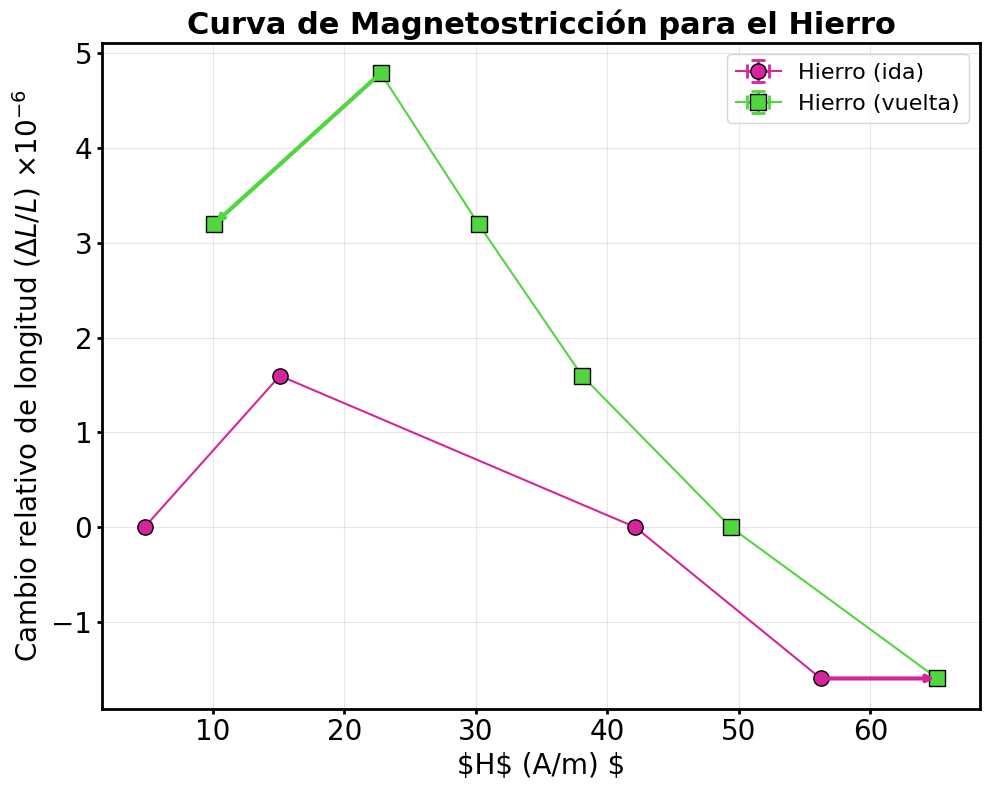

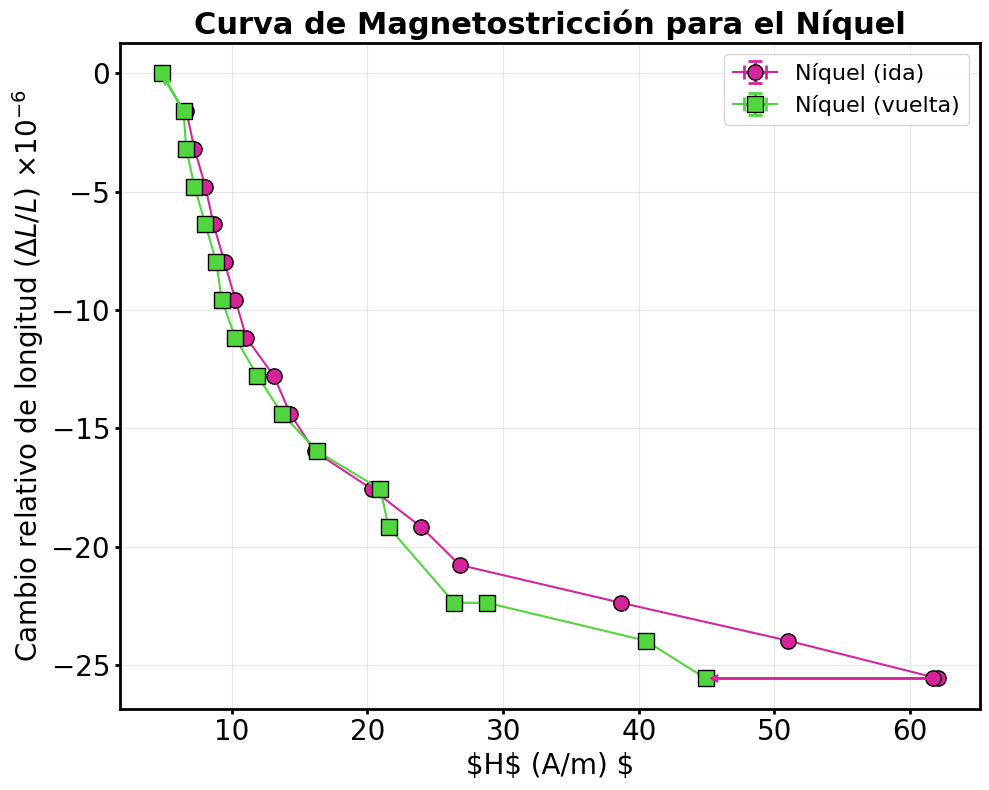

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================
# Parámetros de calibración y constantes
# ============================================

# Regresión B = m I + b (en mT)
m  = 25.3271      # mT/A
dm = 0.0043       # mT/A
b  = 2.5189       # mT
db = 0.0080       # mT

mu_0 = 4 * np.pi * 1e-7   # H/m
sigma_I = 0.01            # A (error de corriente)
sigma_B_inst_mT = 0.01    # mT (error del teslámetro)

lambda_laser = 639e-9     # m (639 nm)

# Longitud de las barras (ajusta si fue otra en el montaje)
L_n = 0.10   # m, Níquel
L_h = 0.10   # m, Hierro

# Colores estilo "premium" de tu gráfica de calibración
color_n1 = "#D6259B"   # rosa fucsia
color_n2 = "#51D63F"   # verde


# ============================================
# Funciones auxiliares
# ============================================

def B_y_H(I):
    """
    Dada una corriente I (array), devuelve:
    - B_mT: inducción en mT
    - H: campo en A/m
    - sigma_H: error en H por propagación de:
        m, b, I (sigma_I) y error instrumental en B
    σ_B^2 = I^2 σ_m^2 + σ_b^2 + m^2 σ_I^2 + σ_B_inst^2
    """
    B_mT = m * I + b
    sigma_B_mT = np.sqrt(
        (I**2) * dm**2 +
        db**2 +
        (m**2) * sigma_I**2 +
        sigma_B_inst_mT**2
    )

    B_T = B_mT * 1e-3
    sigma_B_T = sigma_B_mT * 1e-3

    H = B_T / mu_0
    sigma_H = sigma_B_T / mu_0

    return B_mT, H, sigma_H


def delta_L_rel(n_min, L):
    """
    n_min: número de mínimos (sin error)
    L: longitud de la barra
    Devuelve:
    - delta_rel: ΔL/L
    - sigma_delta_rel: aquí 0, porque asumimos n_min sin incertidumbre
    """
    delta_l = lambda_laser * n_min / 2.0
    delta_rel = delta_l / L
    sigma_delta_rel = np.zeros_like(delta_rel)
    return delta_rel, sigma_delta_rel


def estilo_axes_grandes(ax):
    """Aplicar estilo de ejes similar al de la calibración."""
    ax.tick_params(axis="both", labelsize=20, width=2)
    for spine in ax.spines.values():
        spine.set_linewidth(2)
    ax.grid(True, alpha=0.3)


# ============================================
# Lectura de datos
# (col 0: corriente, col 1: número de mínimo)
# ============================================

niquel = leer_columnas('Niquel.txt')
hierro = leer_columnas('Hierro.txt')

I_n      = niquel[0]
n_min_n  = niquel[1]

I_h      = hierro[0]
n_min_h  = hierro[1]


# ============================================
# Separar ramas de histéresis
# Hierro: 26:30 (ida), 30:36 (vuelta)
# Níquel: 0:17 (ida), 17:36 (vuelta, ajusta si tu archivo es más corto)
# ============================================

# --- Hierro ---
I_h_up   = I_h[26:31]
n_h_up   = n_min_h[26:31]

I_h_down = I_h[30:36]
n_h_down = n_min_h[30:36]

B_h_up,   H_h_up,   sigma_H_h_up   = B_y_H(I_h_up)
B_h_down, H_h_down, sigma_H_h_down = B_y_H(I_h_down)

delta_rel_h_up,   sigma_delta_rel_h_up   = delta_L_rel(n_h_up,   L_h)
delta_rel_h_down, sigma_delta_rel_h_down = delta_L_rel(n_h_down, L_h)

# --- Níquel ---
I_n_up   = I_n[0:18]
n_n_up   = n_min_n[0:18]

I_n_down = I_n[17:36]   # si tu archivo va hasta índice menor, ajusta este rango
n_n_down = n_min_n[17:36]

B_n_up,   H_n_up,   sigma_H_n_up   = B_y_H(I_n_up)
B_n_down, H_n_down, sigma_H_n_down = B_y_H(I_n_down)

delta_rel_n_up,   sigma_delta_rel_n_up   = delta_L_rel(n_n_up,   L_n)
delta_rel_n_down, sigma_delta_rel_n_down = delta_L_rel(n_n_down, L_n)


# ============================================
# Gráfica 1: HIERRO
# ============================================

fig_h, ax_h = plt.subplots(figsize=(10, 8))

# Rampa de ida (color_n1, círculos)
ax_h.errorbar(
    H_h_up * 1e-3,                 # H en 10^3 A/m
    delta_rel_h_up * 1e6,          # ΔL/L en 10^-6
    xerr=sigma_H_h_up * 1e-3,
    yerr=sigma_delta_rel_h_up * 1e6,
    fmt="o-",
    markersize=11,
    mfc=color_n1,
    mec="black",
    elinewidth=2,
    capthick=2,
    capsize=5,
    color=color_n1,
    label="Hierro (ida)"
)

# Flecha para indicar dirección en la rama de ida
ax_h.annotate(
    "",
    xy=(H_h_up[-1] * 1e-3, delta_rel_h_up[-1] * 1e6),
    xytext=(H_h_up[-2] * 1e-3, delta_rel_h_up[-2] * 1e6),
    arrowprops=dict(arrowstyle="->", linewidth=3, color=color_n1)
)

# Rampa de vuelta (color_n2, cuadrados)
ax_h.errorbar(
    H_h_down * 1e-3,
    delta_rel_h_down * 1e6,
    xerr=sigma_H_h_down * 1e-3,
    yerr=sigma_delta_rel_h_down * 1e6,
    fmt="s-",
    markersize=11,
    mfc=color_n2,
    mec="black",
    elinewidth=2,
    capthick=2,
    capsize=5,
    color=color_n2,
    label="Hierro (vuelta)"
)

ax_h.annotate(
    "",
    xy=(H_h_down[-1] * 1e-3, delta_rel_h_down[-1] * 1e6),
    xytext=(H_h_down[-2] * 1e-3, delta_rel_h_down[-2] * 1e6),
    arrowprops=dict(arrowstyle="->", linewidth=3, color=color_n2)
)

ax_h.set_title("Curva de Magnetostricción para el Hierro", fontsize=22, weight="bold")
ax_h.set_xlabel(r"$H$ (A/m) $", fontsize=20)
ax_h.set_ylabel(r"Cambio relativo de longitud ($\Delta L/L$) $\times 10^{-6}$", fontsize=20)

estilo_axes_grandes(ax_h)
ax_h.legend(fontsize=16)
plt.tight_layout()


# ============================================
# Gráfica 2: NIQUEL
# ============================================

fig_n, ax_n = plt.subplots(figsize=(10, 8))

# Rampa de ida (color_n1)
ax_n.errorbar(
    H_n_up * 1e-3,
    delta_rel_n_up * 1e6,
    xerr=sigma_H_n_up * 1e-3,
    yerr=sigma_delta_rel_n_up * 1e6,
    fmt="o-",
    markersize=11,
    mfc=color_n1,
    mec="black",
    elinewidth=2,
    capthick=2,
    capsize=5,
    color=color_n1,
    label="Níquel (ida)"
)

ax_n.annotate(
    "",
    xy=(H_n_up[-1] * 1e-3, delta_rel_n_up[-1] * 1e6),
    xytext=(H_n_up[-2] * 1e-3, delta_rel_n_up[-2] * 1e6),
    arrowprops=dict(arrowstyle="->", linewidth=2, color=color_n1)
)

# Rampa de vuelta (color_n2)
ax_n.errorbar(
    H_n_down * 1e-3,
    delta_rel_n_down * 1e6,
    xerr=sigma_H_n_down * 1e-3,
    yerr=sigma_delta_rel_n_down * 1e6,
    fmt="s-",
    markersize=11,
    mfc=color_n2,
    mec="black",
    elinewidth=2,
    capthick=2,
    capsize=5,
    color=color_n2,
    label="Níquel (vuelta)"
)

ax_n.annotate(
    "",
    xy=(H_n_down[-1] * 1e-3, delta_rel_n_down[-1] * 1e6),
    xytext=(H_n_down[-2] * 1e-3, delta_rel_n_down[-2] * 1e6),
    arrowprops=dict(arrowstyle="->", linewidth=2, color=color_n2)
)

ax_n.set_title("Curva de Magnetostricción para el Níquel", fontsize=22, weight="bold")
ax_n.set_xlabel(r"$H$ (A/m) $", fontsize=20)
ax_n.set_ylabel(r"Cambio relativo de longitud ($\Delta L/L$) $\times 10^{-6}$", fontsize=20)

estilo_axes_grandes(ax_n)
ax_n.legend(fontsize=16)
plt.tight_layout()

plt.show()


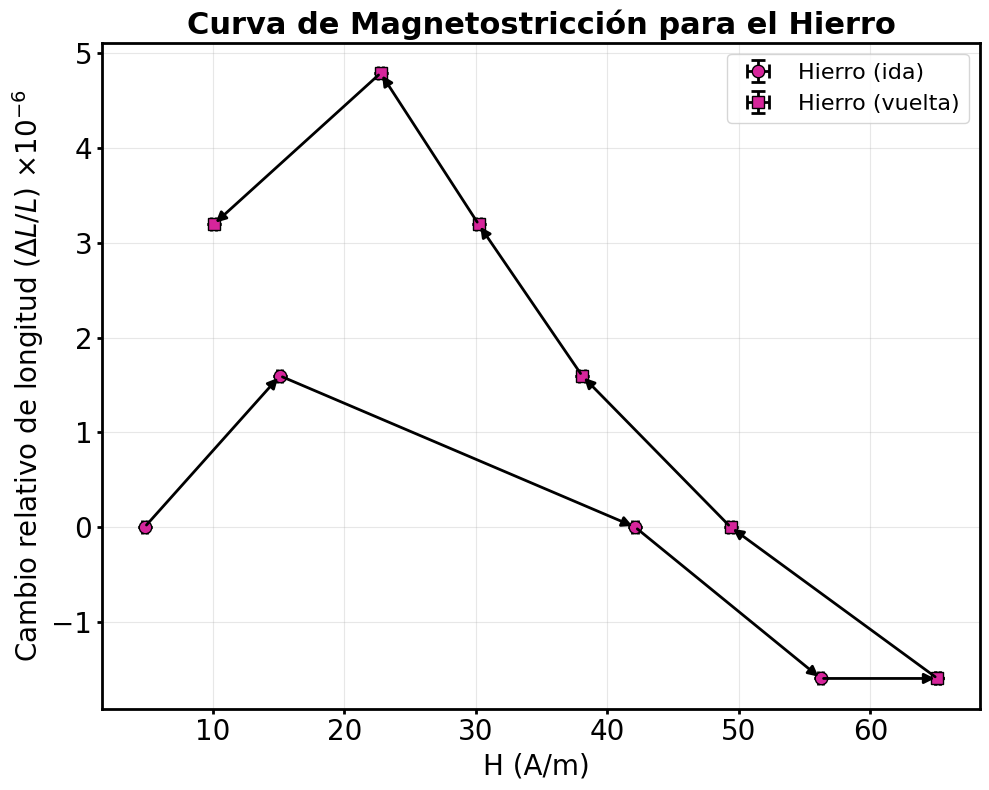

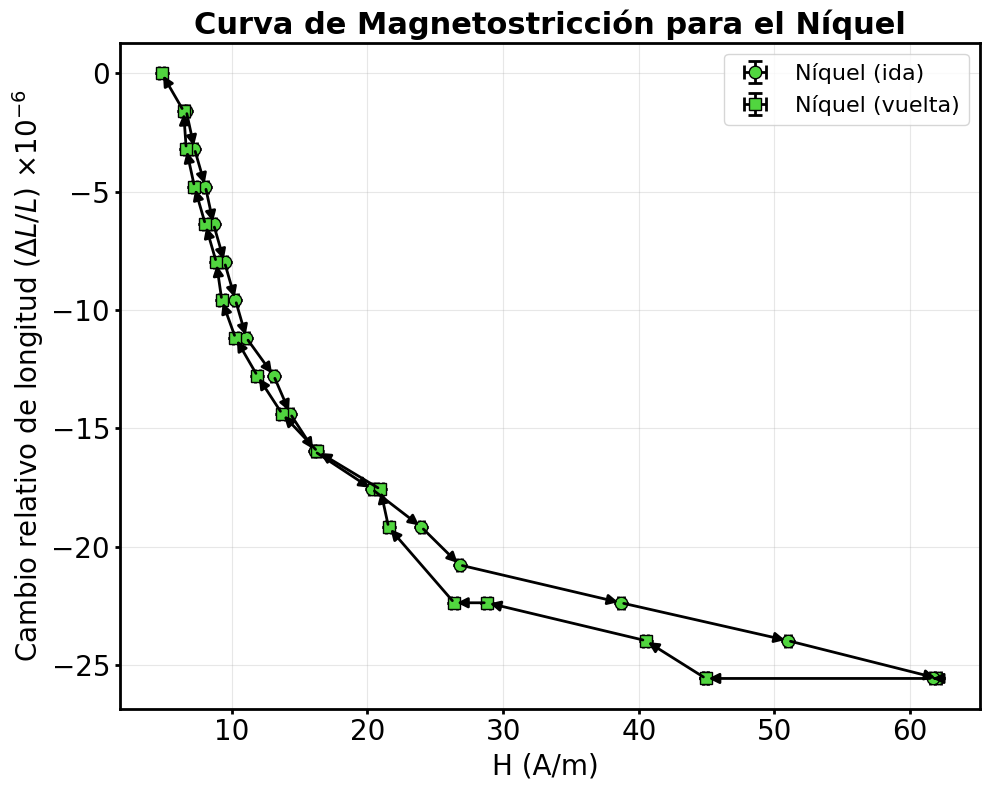

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================
# Parámetros de calibración y constantes
# ============================================

# Regresión B = m I + b (en mT)
m  = 25.3271      # mT/A
dm = 0.0043       # mT/A
b  = 2.5189       # mT
db = 0.0080       # mT

mu_0 = 4 * np.pi * 1e-7   # H/m
sigma_I = 0.01            # A (error de corriente)
sigma_B_inst_mT = 0.01    # mT (error del teslámetro)

lambda_laser = 639e-9     # m (639 nm)

# Longitud de las barras (ajusta si fue otra en el montaje)
L_n = 0.10   # m, Níquel
L_h = 0.10   # m, Hierro

# Colores estilo "premium" de tu gráfica de calibración
color_n1 = "#D6259B"   # rosa fucsia
color_n2 = "#51D63F"   # verde


# ============================================
# Funciones auxiliares
# ============================================

def B_y_H(I):
    """
    Dada una corriente I (array), devuelve:
    - B_mT: inducción en mT
    - H: campo en A/m
    - sigma_H: error en H por propagación de:
        m, b, I (sigma_I) y error instrumental en B
    σ_B^2 = I^2 σ_m^2 + σ_b^2 + m^2 σ_I^2 + σ_B_inst^2
    """
    B_mT = m * I + b
    sigma_B_mT = np.sqrt(
        (I**2) * dm**2 +
        db**2 +
        (m**2) * sigma_I**2 +
        sigma_B_inst_mT**2
    )

    B_T = B_mT * 1e-3
    sigma_B_T = sigma_B_mT * 1e-3

    H = B_T / mu_0
    sigma_H = sigma_B_T / mu_0

    return B_mT, H, sigma_H


def delta_L_rel(n_min, L):
    """
    n_min: número de mínimos (sin error)
    L: longitud de la barra
    Devuelve:
    - delta_rel: ΔL/L
    - sigma_delta_rel: aquí 0, porque asumimos n_min sin incertidumbre
    """
    delta_l = lambda_laser * n_min / 2.0
    delta_rel = delta_l / L
    sigma_delta_rel = np.zeros_like(delta_rel)
    return delta_rel, sigma_delta_rel


def estilo_axes_grandes(ax):
    """Aplicar estilo de ejes similar al de la calibración."""
    ax.tick_params(axis="both", labelsize=20, width=2)
    for spine in ax.spines.values():
        spine.set_linewidth(2)
    ax.grid(True, alpha=0.3)


# ============================================
# Lectura de datos
# (col 0: corriente, col 1: número de mínimo)
# ============================================

niquel = leer_columnas('Niquel.txt')
hierro = leer_columnas('Hierro.txt')

I_n      = niquel[0]
n_min_n  = niquel[1]

I_h      = hierro[0]
n_min_h  = hierro[1]


# ============================================
# Separar ramas de histéresis
# Hierro: 26:30 (ida), 30:36 (vuelta)
# Níquel: 0:17 (ida), 17:36 (vuelta, ajusta si tu archivo es más corto)
# ============================================

# --- Hierro ---
I_h_up   = I_h[26:31]
n_h_up   = n_min_h[26:31]

I_h_down = I_h[30:36]
n_h_down = n_min_h[30:36]

B_h_up,   H_h_up,   sigma_H_h_up   = B_y_H(I_h_up)
B_h_down, H_h_down, sigma_H_h_down = B_y_H(I_h_down)

delta_rel_h_up,   sigma_delta_rel_h_up   = delta_L_rel(n_h_up,   L_h)
delta_rel_h_down, sigma_delta_rel_h_down = delta_L_rel(n_h_down, L_h)

# --- Níquel ---
I_n_up   = I_n[0:18]
n_n_up   = n_min_n[0:18]

I_n_down = I_n[17:36]   # si tu archivo va hasta índice menor, ajusta este rango
n_n_down = n_min_n[17:36]

B_n_up,   H_n_up,   sigma_H_n_up   = B_y_H(I_n_up)
B_n_down, H_n_down, sigma_H_n_down = B_y_H(I_n_down)

delta_rel_n_up,   sigma_delta_rel_n_up   = delta_L_rel(n_n_up,   L_n)
delta_rel_n_down, sigma_delta_rel_n_down = delta_L_rel(n_n_down, L_n)


# ============================================
# Gráfica 1: HIERRO
# ============================================

fig_h, ax_h = plt.subplots(figsize=(10, 8))

# Rampa de ida: puntos + barras de error
ax_h.errorbar(
    H_h_up * 1e-3,                 # H en 10^3 A/m
    delta_rel_h_up * 1e6,          # ΔL/L en 10^-6
    xerr=sigma_H_h_up * 1e-3,
    yerr=sigma_delta_rel_h_up * 1e6,
    fmt="o",
    markersize=9,
    mfc=color_n1,
    mec="black",
    ecolor="black",
    elinewidth=2,
    capthick=2,
    capsize=5,
    linestyle="none",
    label="Hierro (ida)"
)

# Rampa de vuelta: puntos + barras de error (mismo color)
ax_h.errorbar(
    H_h_down * 1e-3,
    delta_rel_h_down * 1e6,
    xerr=sigma_H_h_down * 1e-3,
    yerr=sigma_delta_rel_h_down * 1e6,
    fmt="s",
    markersize=9,
    mfc=color_n1,
    mec="black",
    ecolor="black",
    elinewidth=2,
    capthick=2,
    capsize=5,
    linestyle="none",
    label="Hierro (vuelta)"
)

# Flechas negras entre cada par de puntos (ida)
for i in range(len(H_h_up) - 1):
    x0 = H_h_up[i]   * 1e-3
    y0 = delta_rel_h_up[i]   * 1e6
    x1 = H_h_up[i+1] * 1e-3
    y1 = delta_rel_h_up[i+1] * 1e6
    ax_h.annotate(
        "",
        xy=(x1, y1),
        xytext=(x0, y0),
        arrowprops=dict(
            arrowstyle="-|>",
            linewidth=2,
            color="black",
            mutation_scale=15
        ),
        zorder=4
    )

# Flechas negras entre cada par de puntos (vuelta)
for i in range(len(H_h_down) - 1):
    x0 = H_h_down[i]   * 1e-3
    y0 = delta_rel_h_down[i]   * 1e6
    x1 = H_h_down[i+1] * 1e-3
    y1 = delta_rel_h_down[i+1] * 1e6
    ax_h.annotate(
        "",
        xy=(x1, y1),
        xytext=(x0, y0),
        arrowprops=dict(
            arrowstyle="-|>",
            linewidth=2,
            color="black",
            mutation_scale=15
        ),
        zorder=4
    )

ax_h.set_title("Curva de Magnetostricción para el Hierro", fontsize=22, weight="bold")
ax_h.set_xlabel(r"H (A/m) ", fontsize=20)
ax_h.set_ylabel(r"Cambio relativo de longitud ($\Delta L/L$) $\times 10^{-6}$", fontsize=20)

estilo_axes_grandes(ax_h)
ax_h.legend(fontsize=16)
plt.tight_layout()


# ============================================
# Gráfica 2: NIQUEL
# ============================================

fig_n, ax_n = plt.subplots(figsize=(10, 8))

# Rampa de ida: puntos + barras de error
ax_n.errorbar(
    H_n_up * 1e-3,
    delta_rel_n_up * 1e6,
    xerr=sigma_H_n_up * 1e-3,
    yerr=sigma_delta_rel_n_up * 1e6,
    fmt="o",
    markersize=9,
    mfc=color_n2,
    mec="black",
    ecolor="black",
    elinewidth=2,
    capthick=2,
    capsize=5,
    linestyle="none",
    label="Níquel (ida)"
)

# Rampa de vuelta: puntos + barras de error (mismo color)
ax_n.errorbar(
    H_n_down * 1e-3,
    delta_rel_n_down * 1e6,
    xerr=sigma_H_n_down * 1e-3,
    yerr=sigma_delta_rel_n_down * 1e6,
    fmt="s",
    markersize=9,
    mfc=color_n2,
    mec="black",
    ecolor="black",
    elinewidth=2,
    capthick=2,
    capsize=5,
    linestyle="none",
    label="Níquel (vuelta)"
)

# Flechas negras entre cada par de puntos (ida)
for i in range(len(H_n_up) - 1):
    x0 = H_n_up[i]   * 1e-3
    y0 = delta_rel_n_up[i]   * 1e6
    x1 = H_n_up[i+1] * 1e-3
    y1 = delta_rel_n_up[i+1] * 1e6
    ax_n.annotate(
        "",
        xy=(x1, y1),
        xytext=(x0, y0),
        arrowprops=dict(
            arrowstyle="-|>",
            linewidth=2,
            color="black",
            mutation_scale=15
        ),
        zorder=4
    )

# Flechas negras entre cada par de puntos (vuelta)
for i in range(len(H_n_down) - 1):
    x0 = H_n_down[i]   * 1e-3
    y0 = delta_rel_n_down[i]   * 1e6
    x1 = H_n_down[i+1] * 1e-3
    y1 = delta_rel_n_down[i+1] * 1e6
    ax_n.annotate(
        "",
        xy=(x1, y1),
        xytext=(x0, y0),
        arrowprops=dict(
            arrowstyle="-|>",
            linewidth=2,
            color="black",
            mutation_scale=15
        ),
        zorder=4
    )

ax_n.set_title("Curva de Magnetostricción para el Níquel", fontsize=22, weight="bold")
ax_n.set_xlabel(r"H (A/m) ", fontsize=20)
ax_n.set_ylabel(r"Cambio relativo de longitud ($\Delta L/L$) $\times 10^{-6}$", fontsize=20)

estilo_axes_grandes(ax_n)
ax_n.legend(fontsize=16)
plt.tight_layout()

plt.show()


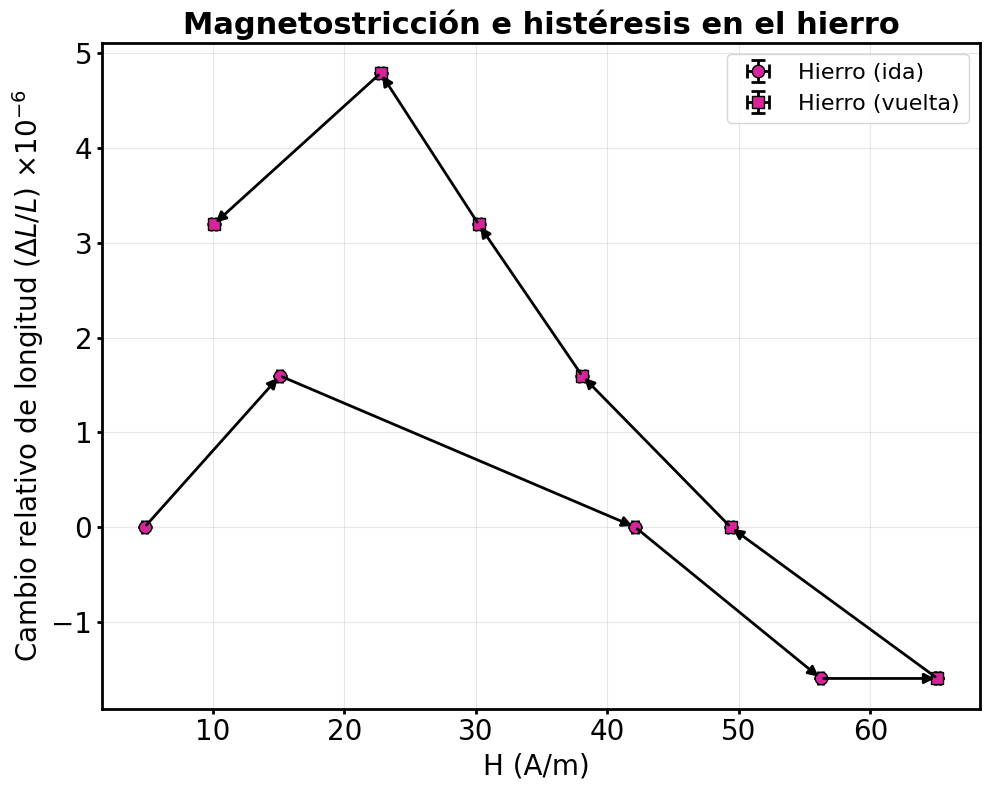

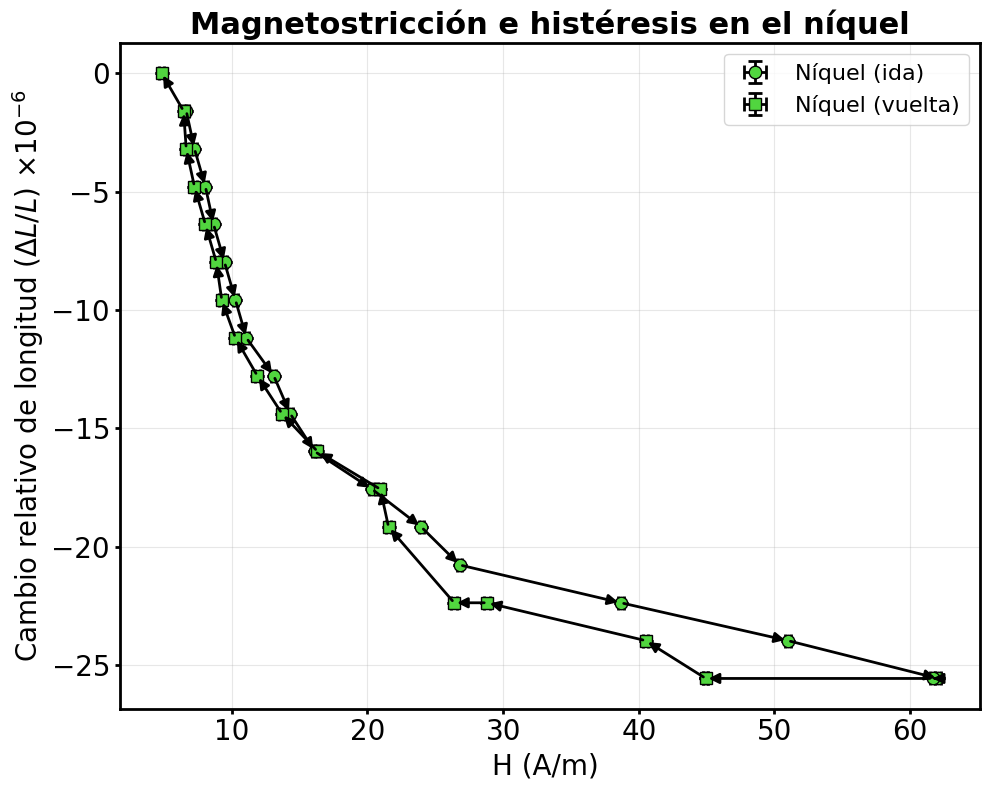

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================
# Parámetros de calibración y constantes
# ============================================

# Regresión B = m I + b (en mT)
m  = 25.3271      # mT/A
dm = 0.0043       # mT/A
b  = 2.5189       # mT
db = 0.0080       # mT

mu_0 = 4 * np.pi * 1e-7   # H/m
sigma_I = 0.01            # A (error de corriente)
sigma_B_inst_mT = 0.01    # mT (error del teslámetro)

lambda_laser = 639e-9     # m (639 nm)

# Longitud de las barras (ajusta si fue otra en el montaje)
L_n = 0.10   # m, Níquel
L_h = 0.10   # m, Hierro

# Colores estilo "premium" de tu gráfica de calibración
color_n1 = "#D6259B"   # rosa fucsia
color_n2 = "#51D63F"   # verde


# ============================================
# Funciones auxiliares
# ============================================

def B_y_H(I):
    """
    Dada una corriente I (array), devuelve:
    - B_mT: inducción en mT
    - H: campo en A/m
    - sigma_H: error en H por propagación de:
        m, b, I (sigma_I) y error instrumental en B
    σ_B^2 = I^2 σ_m^2 + σ_b^2 + m^2 σ_I^2 + σ_B_inst^2
    """
    B_mT = m * I + b
    sigma_B_mT = np.sqrt(
        (I**2) * dm**2 +
        db**2 +
        (m**2) * sigma_I**2 +
        sigma_B_inst_mT**2
    )

    B_T = B_mT * 1e-3
    sigma_B_T = sigma_B_mT * 1e-3

    H = B_T / mu_0
    sigma_H = sigma_B_T / mu_0

    return B_mT, H, sigma_H


def delta_L_rel(n_min, L):
    """
    n_min: número de mínimos (sin error)
    L: longitud de la barra
    Devuelve:
    - delta_rel: ΔL/L
    - sigma_delta_rel: aquí 0, porque asumimos n_min sin incertidumbre
    """
    delta_l = lambda_laser * n_min / 2.0
    delta_rel = delta_l / L
    sigma_delta_rel = np.zeros_like(delta_rel)
    return delta_rel, sigma_delta_rel


def estilo_axes_grandes(ax):
    """Aplicar estilo de ejes similar al de la calibración."""
    ax.tick_params(axis="both", labelsize=20, width=2)
    for spine in ax.spines.values():
        spine.set_linewidth(2)
    ax.grid(True, alpha=0.3)


# ============================================
# Lectura de datos
# (col 0: corriente, col 1: número de mínimo)
# ============================================

niquel = leer_columnas('Niquel.txt')
hierro = leer_columnas('Hierro.txt')

I_n      = niquel[0]
n_min_n  = niquel[1]

I_h      = hierro[0]
n_min_h  = hierro[1]


# ============================================
# Separar ramas de histéresis
# Hierro: 26:30 (ida), 30:36 (vuelta)
# Níquel: 0:17 (ida), 17:36 (vuelta, ajusta si tu archivo es más corto)
# ============================================

# --- Hierro ---
I_h_up   = I_h[26:31]
n_h_up   = n_min_h[26:31]

I_h_down = I_h[30:36]
n_h_down = n_min_h[30:36]

B_h_up,   H_h_up,   sigma_H_h_up   = B_y_H(I_h_up)
B_h_down, H_h_down, sigma_H_h_down = B_y_H(I_h_down)

delta_rel_h_up,   sigma_delta_rel_h_up   = delta_L_rel(n_h_up,   L_h)
delta_rel_h_down, sigma_delta_rel_h_down = delta_L_rel(n_h_down, L_h)

# --- Níquel ---
I_n_up   = I_n[0:18]
n_n_up   = n_min_n[0:18]

I_n_down = I_n[17:36]   # si tu archivo va hasta índice menor, ajusta este rango
n_n_down = n_min_n[17:36]

B_n_up,   H_n_up,   sigma_H_n_up   = B_y_H(I_n_up)
B_n_down, H_n_down, sigma_H_n_down = B_y_H(I_n_down)

delta_rel_n_up,   sigma_delta_rel_n_up   = delta_L_rel(n_n_up,   L_n)
delta_rel_n_down, sigma_delta_rel_n_down = delta_L_rel(n_n_down, L_n)


# ============================================
# Gráfica 1: HIERRO
# ============================================

fig_h, ax_h = plt.subplots(figsize=(10, 8))

# Rampa de ida: puntos + barras de error
ax_h.errorbar(
    H_h_up * 1e-3,                 # H en 10^3 A/m
    delta_rel_h_up * 1e6,          # ΔL/L en 10^-6
    xerr=sigma_H_h_up * 1e-3,
    yerr=sigma_delta_rel_h_up * 1e6,
    fmt="o",
    markersize=9,
    mfc=color_n1,
    mec="black",
    ecolor="black",
    elinewidth=2,
    capthick=2,
    capsize=5,
    linestyle="none",
    label="Hierro (ida)"
)

# Rampa de vuelta: puntos + barras de error (mismo color)
ax_h.errorbar(
    H_h_down * 1e-3,
    delta_rel_h_down * 1e6,
    xerr=sigma_H_h_down * 1e-3,
    yerr=sigma_delta_rel_h_down * 1e6,
    fmt="s",
    markersize=9,
    mfc=color_n1,
    mec="black",
    ecolor="black",
    elinewidth=2,
    capthick=2,
    capsize=5,
    linestyle="none",
    label="Hierro (vuelta)"
)

# Flechas negras entre cada par de puntos (ida)
for i in range(len(H_h_up) - 1):
    x0 = H_h_up[i]   * 1e-3
    y0 = delta_rel_h_up[i]   * 1e6
    x1 = H_h_up[i+1] * 1e-3
    y1 = delta_rel_h_up[i+1] * 1e6
    ax_h.annotate(
        "",
        xy=(x1, y1),
        xytext=(x0, y0),
        arrowprops=dict(
            arrowstyle="-|>",
            linewidth=2,
            color="black",
            mutation_scale=15
        ),
        zorder=4
    )

# Flechas negras entre cada par de puntos (vuelta)
for i in range(len(H_h_down) - 1):
    x0 = H_h_down[i]   * 1e-3
    y0 = delta_rel_h_down[i]   * 1e6
    x1 = H_h_down[i+1] * 1e-3
    y1 = delta_rel_h_down[i+1] * 1e6
    ax_h.annotate(
        "",
        xy=(x1, y1),
        xytext=(x0, y0),
        arrowprops=dict(
            arrowstyle="-|>",
            linewidth=2,
            color="black",
            mutation_scale=15
        ),
        zorder=4
    )

ax_h.set_title("Magnetostricción e histéresis en el hierro", fontsize=22, weight="bold")
ax_h.set_xlabel(r"H (A/m) ", fontsize=20)
ax_h.set_ylabel(r"Cambio relativo de longitud ($\Delta L/L$) $\times 10^{-6}$", fontsize=20)

estilo_axes_grandes(ax_h)
ax_h.legend(fontsize=16)
plt.tight_layout()


# ============================================
# Gráfica 2: NIQUEL
# ============================================

fig_n, ax_n = plt.subplots(figsize=(10, 8))

# Rampa de ida: puntos + barras de error
ax_n.errorbar(
    H_n_up * 1e-3,
    delta_rel_n_up * 1e6,
    xerr=sigma_H_n_up * 1e-3,
    yerr=sigma_delta_rel_n_up * 1e6,
    fmt="o",
    markersize=9,
    mfc=color_n2,
    mec="black",
    ecolor="black",
    elinewidth=2,
    capthick=2,
    capsize=5,
    linestyle="none",
    label="Níquel (ida)"
)

# Rampa de vuelta: puntos + barras de error (mismo color)
ax_n.errorbar(
    H_n_down * 1e-3,
    delta_rel_n_down * 1e6,
    xerr=sigma_H_n_down * 1e-3,
    yerr=sigma_delta_rel_n_down * 1e6,
    fmt="s",
    markersize=9,
    mfc=color_n2,
    mec="black",
    ecolor="black",
    elinewidth=2,
    capthick=2,
    capsize=5,
    linestyle="none",
    label="Níquel (vuelta)"
)

# Flechas negras entre cada par de puntos (ida)
for i in range(len(H_n_up) - 1):
    x0 = H_n_up[i]   * 1e-3
    y0 = delta_rel_n_up[i]   * 1e6
    x1 = H_n_up[i+1] * 1e-3
    y1 = delta_rel_n_up[i+1] * 1e6
    ax_n.annotate(
        "",
        xy=(x1, y1),
        xytext=(x0, y0),
        arrowprops=dict(
            arrowstyle="-|>",
            linewidth=2,
            color="black",
            mutation_scale=15
        ),
        zorder=4
    )

# Flechas negras entre cada par de puntos (vuelta)
for i in range(len(H_n_down) - 1):
    x0 = H_n_down[i]   * 1e-3
    y0 = delta_rel_n_down[i]   * 1e6
    x1 = H_n_down[i+1] * 1e-3
    y1 = delta_rel_n_down[i+1] * 1e6
    ax_n.annotate(
        "",
        xy=(x1, y1),
        xytext=(x0, y0),
        arrowprops=dict(
            arrowstyle="-|>",
            linewidth=2,
            color="black",
            mutation_scale=15
        ),
        zorder=4
    )

ax_n.set_title("Magnetostricción e histéresis en el níquel", fontsize=22, weight="bold")
ax_n.set_xlabel(r"H (A/m) ", fontsize=20)
ax_n.set_ylabel(r"Cambio relativo de longitud ($\Delta L/L$) $\times 10^{-6}$", fontsize=20)

estilo_axes_grandes(ax_n)
ax_n.legend(fontsize=16)
plt.tight_layout()

plt.show()
